# Code

## Imports

In [25]:
# plot_data.py
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
import matplotlib as mpl
from matplotlib import font_manager

## Data extraction from csv

## Load 

In [ ]:
df = pd.read_csv("data.csv", sep=";")

## Extract fields

In [ ]:

t = df["t"].to_numpy()
fsm = df["FSM/CurrentState"].to_numpy()  # Contiene gli interi 0, 1, 2

# --- LEFT ARM (Braccio Sinistro) ---
# Forze (Error, Measured, Target)
l_force_meas = df[["DualArmControl_Arms/Left_Force_Measured_x", "DualArmControl_Arms/Left_Force_Measured_y", "DualArmControl_Arms/Left_Force_Measured_z"]].to_numpy()
l_force_targ = df[["DualArmControl_Arms/Left_Force_Target_x", "DualArmControl_Arms/Left_Force_Target_y", "DualArmControl_Arms/Left_Force_Target_z"]].to_numpy()

# Posa (Actual, Target, Error Norm)
l_pose_act = df[["DualArmControl_Arms/Left_Pose_Actual_x", "DualArmControl_Arms/Left_Pose_Actual_y", "DualArmControl_Arms/Left_Pose_Actual_z"]].to_numpy()
l_pose_targ = df[["DualArmControl_Arms/Left_Pose_Target_x", "DualArmControl_Arms/Left_Pose_Target_y", "DualArmControl_Arms/Left_Pose_Target_z"]].to_numpy()
l_pose_err_norm = df["DualArmControl_Arms/Left_Pose_Error_Norm"].to_numpy()

# --- RIGHT ARM (Braccio Destro) ---
# Nota: Nel tuo CSV per il braccio destro c'è l'underscore "_" al posto dello slash "/" dopo "Arms"
# Forze (Error, Measured, Target)
r_force_meas = df[["DualArmControl_Arms_Right_Force_Measured_x", "DualArmControl_Arms_Right_Force_Measured_y", "DualArmControl_Arms_Right_Force_Measured_z"]].to_numpy()
r_force_targ = df[["DualArmControl_Arms_Right_Force_Target_x", "DualArmControl_Arms_Right_Force_Target_y", "DualArmControl_Arms_Right_Force_Target_z"]].to_numpy()

# Posa (Actual, Target, Error Norm)
r_pose_act = df[["DualArmControl_Arms_Right_Pose_Actual_x", "DualArmControl_Arms_Right_Pose_Actual_y", "DualArmControl_Arms_Right_Pose_Actual_z"]].to_numpy()
r_pose_targ = df[["DualArmControl_Arms_Right_Pose_Target_x", "DualArmControl_Arms_Right_Pose_Target_y", "DualArmControl_Arms_Right_Pose_Target_z"]].to_numpy()
r_pose_err_norm = df["DualArmControl_Arms_Right_Pose_Error_Norm"].to_numpy()

# --- OBJECT & INTERNAL FORCES (Oggetto manipolato e Forze Interne) ---
# Forze Interne (Lambda) e Controllo
obj_lambda_filt = df["DualArmControl_Object_InternalForces_Lambda_Filtered"].to_numpy()
obj_lambda_meas = df["DualArmControl_Object_InternalForces_Lambda_Measured"].to_numpy()

# Traiettoria Oggetto (Actual, Desired, Errors)
obj_traj_act = df[["DualArmControl_Object_Trajectory_Actual_x", "DualArmControl_Object_Trajectory_Actual_y", "DualArmControl_Object_Trajectory_Actual_z"]].to_numpy()
obj_traj_des = df[["DualArmControl_Object_Trajectory_Desired_x", "DualArmControl_Object_Trajectory_Desired_y", "DualArmControl_Object_Trajectory_Desired_z"]].to_numpy()
obj_traj_err_xyz = df[["DualArmControl_Object_Trajectory_Error_XYZ_x", "DualArmControl_Object_Trajectory_Error_XYZ_y", "DualArmControl_Object_Trajectory_Error_XYZ_z"]].to_numpy()
obj_traj_err_ori_rad = df["DualArmControl_Object_Trajectory_Error_Orientation_Rad"].to_numpy()

## Template design

In [27]:
import matplotlib.pyplot as plt
import numpy as np
from matplotlib import font_manager  # Fixed: Missing import for font handling

# ---------- Load custom font ----------
#FONT_PATH = "fonts/Lato/Lato-Black.ttf"
FONT_PATH = "fonts/Roboto/static/Roboto_Condensed-ExtraLight.ttf"
font_manager.fontManager.addfont(FONT_PATH)
FONT_NAME = font_manager.FontProperties(fname=FONT_PATH).get_name()


def apply_academic_style():
    """Applies a unified, clean, large-font academic style to all notebook plots."""
    plt.rcParams.update(
        {
            "font.family": FONT_NAME,
            "font.size": 20,
            "axes.labelsize": 16,     # Large, clear axis labels
            "xtick.labelsize": 14,    # Large axis tick numbers
            "ytick.labelsize": 14,    # Large axis tick numbers
            "text.color": "#222222",
            "axes.labelcolor": "#222222",
            "xtick.color": "#222222",
            "ytick.color": "#222222",
            "figure.constrained_layout.use": True,
            # Force LaTeX math elements to use your custom serif/sans font style
            "mathtext.fontset": "custom",
            "mathtext.rm": FONT_NAME,
            "mathtext.it": f"{FONT_NAME}:italic",
            "mathtext.bf": f"{FONT_NAME}:bold",
        }
    )

def format_academic_axes(ax):
    """Applies the clean background grid and removes the top/right borders."""
    ax.grid(True, linestyle=":", color="#E0E0E0", lw=0.8, zorder=1)
    ax.axhline(0, color="#CCCCCC", lw=0.8, linestyle="-", zorder=1)
    ax.axvline(0, color="#CCCCCC", lw=0.8, linestyle="-", zorder=1)
    
    for spine in ["top", "right"]:
        ax.spines[spine].set_visible(False)
    for spine in ["left", "bottom"]:
        ax.spines[spine].set_color("#333333")
        ax.spines[spine].set_linewidth(0.8)


# Run the setup functions
apply_academic_style()

# Unified Professional Palette Constants
COLOR_BASE = "#333333"    # Primary lines, axes, text
COLOR_ACCENT = "#005587"  # Focal points, end markers
COLOR_MUTED = "#777777"   # Subdued markers, timestamps

## Plot 1
* Configurazione assi su mc_log_ui:
  - ASSE X: Object/Trajectory/Error_XYZ_y (oppure componente dell'asse di spinta)
  - ASSE Y: Object/InternalForces/Lambda_Error
* Cosa rivela: Analisi di stabilità. Prima del contatto l'errore di forza è zero 
  e l'errore di posizione cala. Al contatto, l'asse X si stabilizza e l'errore 
  di forza (asse Y) deve convergere a zero. Traiettorie a spirale indicano un 
  buon smorzamento; cicli chiusi (ovali) indicano oscillazioni persistenti del PI.


GRAFICO 2: TRACKING CINEMATICO E SFORZO RISULTANTE
-------------------------------------------------------------------------------
* Configurazione assi su mc_log_ui (Stesso asse X temporale 't'):
  - FINESTRA SUPERIORE (Y1): Object/Trajectory/Desired e Object/Trajectory/Actual
  - FINESTRA INFERIORE (Y2): Object/Resultant/Net_Force (componenti x, y, z)
* Nota di Cautela Dinamica: In quasi-statica, Net_Force_z tenderà a zero solo se 
  l'algoritmo effettua la compensazione online del peso dell'oggetto nel QP. In 
  caso contrario, l'asse Z registrerà stabilmente la forza di gravità dell'oggetto 
  (m * g), mentre gli assi X e Y simuleranno gli attriti d'accoppiamento.
* Cosa rivela: Correla istantaneamente una deviazione millimetrica nel tracking 
  geometrico dell'oggetto con l'insorgenza di picchi anomali di forza netta.

In [28]:
# 1. Trova l'indice di inizio dello stato FSM 2
start_idx = np.where(fsm == 2)[0][0]

# 2. Taglia tutti i segnali da quel punto in poi creando le variabili per il plot
t_plot = t[start_idx:]
obj_traj_act_plot = obj_traj_act[start_idx:]
obj_traj_des_plot = obj_traj_des[start_idx:]




norm_des = np.linalg.norm(obj_traj_des_plot, axis=1)
norm_act = np.linalg.norm(obj_traj_act_plot, axis=1)
obj_int = obj_lambda_meas[start_idx:]

# 3. Controllo di sicurezza: taglia alla lunghezza minima comune per evitare mismatch di dimensioni





findfont: Font family ['cursive'] not found. Falling back to DejaVu Sans.
findfont: Generic family 'cursive' not found because none of the following families were found: Apple Chancery, Textile, Zapf Chancery, Sand, Script MT, Felipa, Comic Neue, Comic Sans MS, cursive


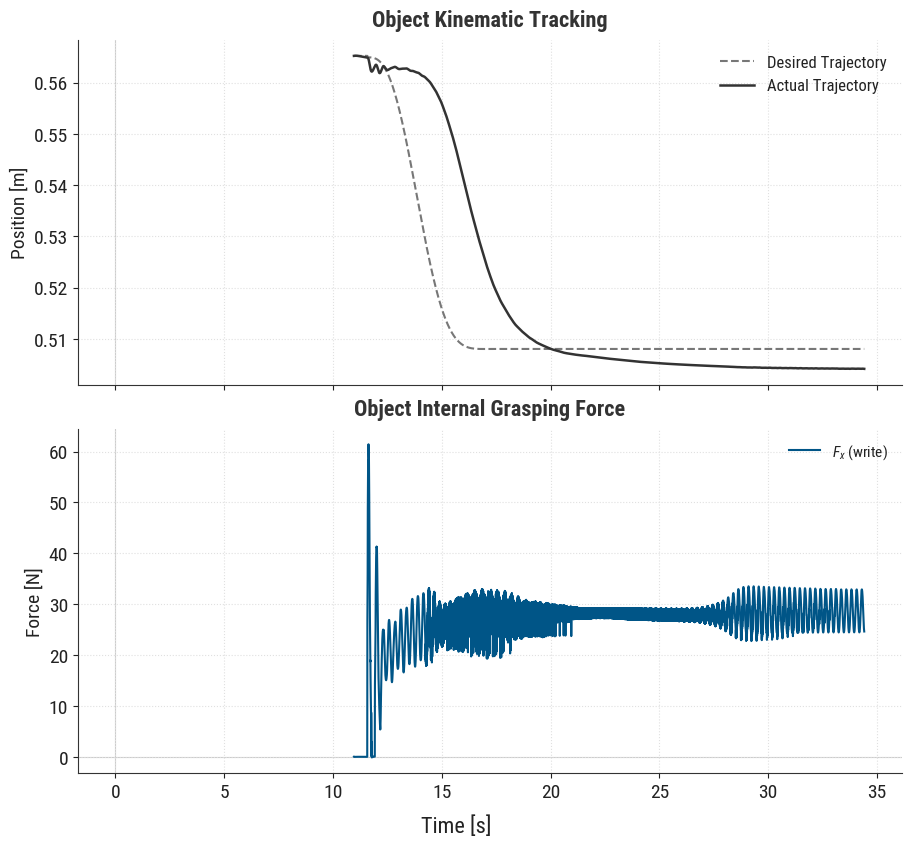

In [29]:
# -------------------------------------------------------------------------------
# GRAFICO 2: TRACKING CINEMATICO E SFORZO RISULTANTE (CORRETTO)
# -------------------------------------------------------------------------------

# 1. Calcolo preventivo delle norme ed esecuzione degli zoom adattivi


# --- Configurazione Zoom Traiettoria (ax1) ---
y1_min = min(np.min(norm_des), np.min(norm_act))
y1_max = max(np.max(norm_des), np.max(norm_act))
y1_margin = (y1_max - y1_min) * 0.05
if y1_margin == 0: y1_margin = 0.02  # Default di sicurezza se il segnale è costante




# 2. Inizializzazione subplots verticali con asse X condiviso
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(9, 8), sharex=True)

# Applica la griglia accademica e il despining a entrambi i pannelli
format_academic_axes(ax1)
format_academic_axes(ax2)

# Palette di colori specifica per componenti (X, Y, Z) per mantenere ordine visivo
COLOR_X = "#005587"  # Blu Accent
COLOR_Y = "#CC6600"  # Arancio Muted
COLOR_Z = "#333333"  # Grigio Base


# ==========================================
# FINESTRA SUPERIORE (ax1): Tracking Cinematico
# ==========================================
ax1.plot(t_plot, norm_des, "--", color=COLOR_MUTED, lw=1.5, label="Desired Trajectory")
ax1.plot(t_plot, norm_act, "-", color=COLOR_BASE, lw=1.8, label="Actual Trajectory")

ax1.set_title("Object Kinematic Tracking", fontsize=16, pad=10, weight="bold", color=COLOR_BASE)
ax1.set_ylabel("Position [m]", fontsize=14)
ax1.legend(loc="upper right", frameon=False, fontsize=12)

# Applicazione zoom adattivo (taglia gli offset inutili partendo da 0)
ax1.set_ylim(y1_min - y1_margin, y1_max + y1_margin)


# ==========================================
# FINESTRA INFERIORE (ax2): Forze Nette Risultanti
# ==========================================
#ax2.plot(t_plot, obj_net_force_plot[:, 0], "-", color=COLOR_X, lw=1.5, label=r"$F_x$ (write)")
#ax2.plot(t_plot, obj_net_force_plot[:, 1], "-", color=COLOR_Y, lw=1.5, label=r"$F_y$ (write)")
#ax2.plot(t_plot, obj_net_force_plot[:, 2], "-", color=COLOR_Z, lw=1.8, label=r"$F_z$ (write)")
#ax2.set_title("Object Resultant Net Force", fontsize=16, pad=10, weight="bold", color=COLOR_BASE)

ax2.plot(t_plot, obj_int, "-", color=COLOR_X, lw=1.5, label=r"$F_x$ (write)")
ax2.set_title("Object Internal Grasping Force", fontsize=16, pad=10, weight="bold", color=COLOR_BASE)

ax2.set_ylabel("Force [N]", fontsize=14)
ax2.legend(loc="upper right", frameon=False, fontsize=11)

# ==========================================
# LAYOUT E ASSE X CENTRATO
# ==========================================
fig.get_layout_engine().set(rect=(0, 0.06, 1, 1))
fig.supxlabel("Time [s]", fontsize=16, y=0.02)

plt.show()

foze 

In [30]:
t_plot_force = t[start_idx:]


# Braccio destro
r_force_meas = r_force_meas[start_idx:]
r_force_targ = r_force_targ[start_idx:]

r_force_err = r_force_targ - r_force_meas


# Braccio sinistro
l_force_meas = l_force_meas[start_idx:]
l_force_targ = l_force_targ[start_idx:]

l_force_err = l_force_targ - l_force_meas




print(t_plot_force.shape)


(23453,)


/tmp/ipykernel_6580/1995404359.py:62: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


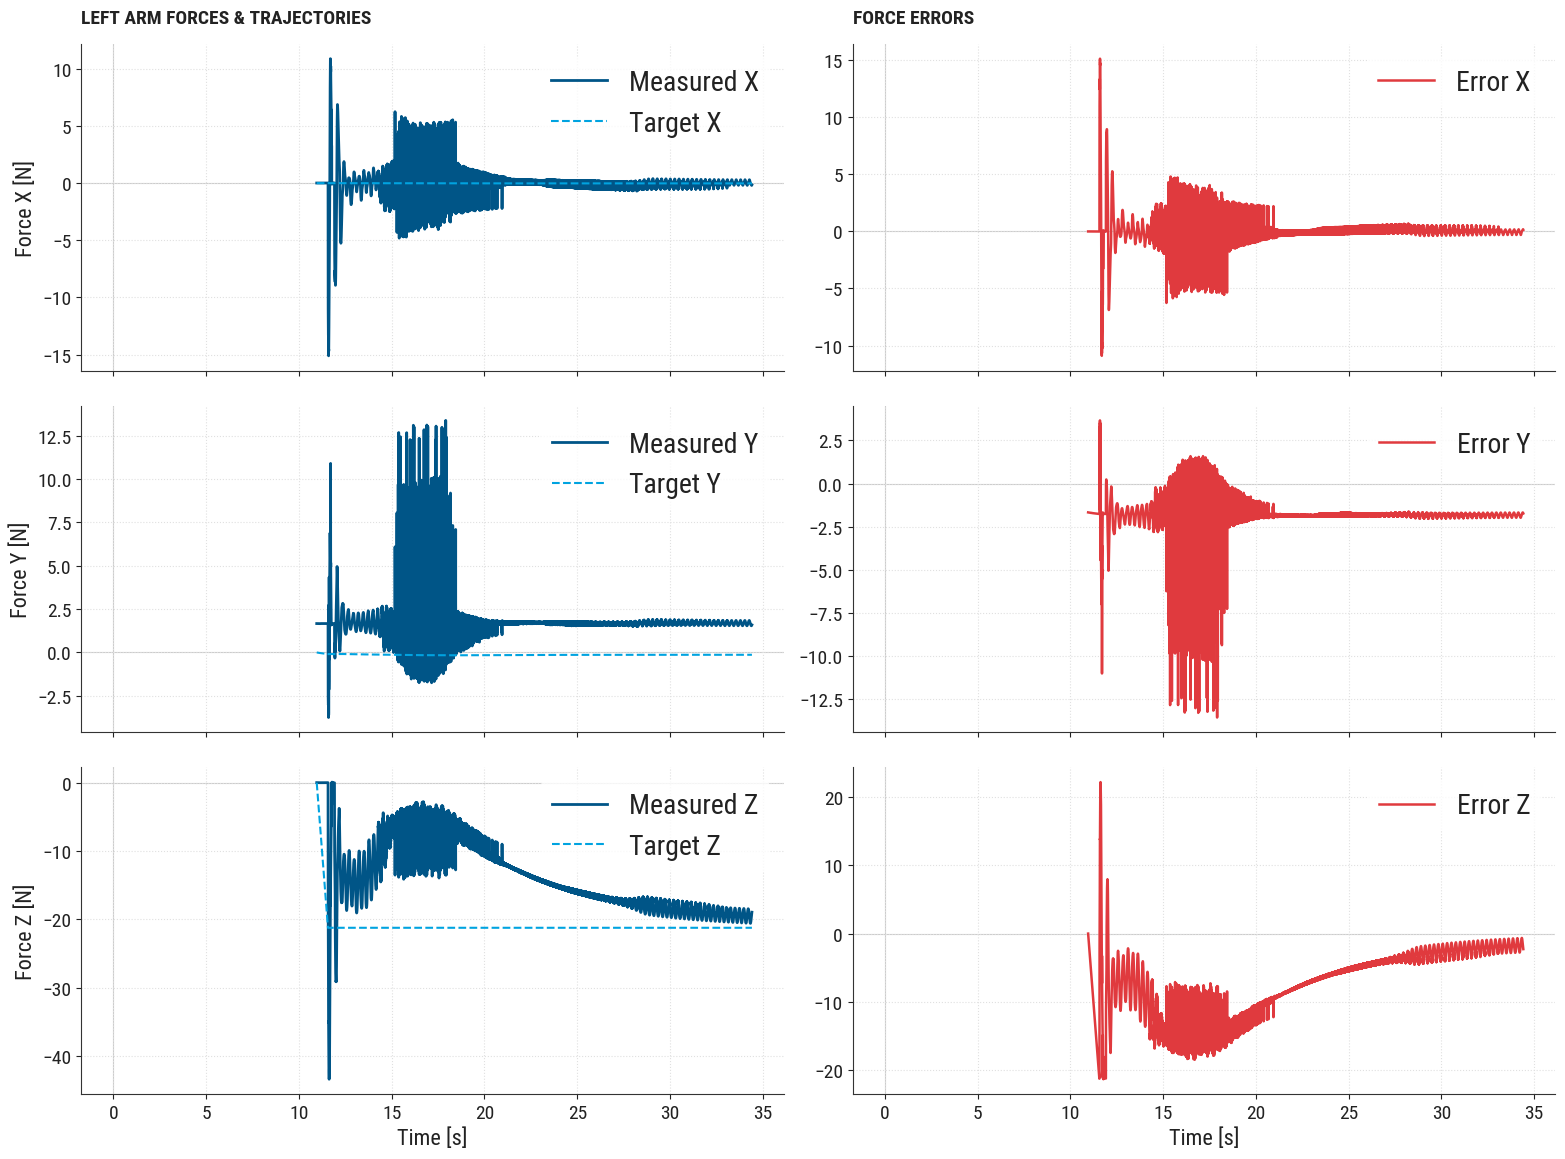

In [31]:
# Griglia 3x2: 3 righe (X, Y, Z), 2 colonne (Dati a sinistra, Errori a destra)
fig, axs = plt.subplots(3, 2, figsize=(16, 12), sharex=True)

# Disimballiamo la matrice degli assi per comodità
(ax_x, ax_x_err) = axs[0]
(ax_y, ax_y_err) = axs[1]
(ax_z, ax_z_err) = axs[2]

# --- TITOLI DELLE COLONNE ---
ax_x.set_title("LEFT ARM FORCES & TRAJECTORIES", loc="left", fontsize=14, fontweight="bold", pad=15)
ax_x_err.set_title("FORCE ERRORS", loc="left", fontsize=14, fontweight="bold", pad=15)

# ==========================================
# COLONNA DI SINISTRA: MISURE E TARGET
# ==========================================

# Subplot X (Sinistra)
ax_x.plot(t_plot_force, l_force_meas[:, 0], label="Measured X", color=COLOR_ACCENT, lw=2)
ax_x.plot(t_plot_force, l_force_targ[:, 0], label="Target X", color="#00a3e0", linestyle="--", lw=1.5)
ax_x.set_ylabel("Force X [N]")
ax_x.legend(loc="upper right", frameon=True, facecolor="white", edgecolor="none")
format_academic_axes(ax_x)

# Subplot Y (Sinistra)
ax_y.plot(t_plot_force, l_force_meas[:, 1], label="Measured Y", color=COLOR_ACCENT, lw=2)
ax_y.plot(t_plot_force, l_force_targ[:, 1], label="Target Y", color="#00a3e0", linestyle="--", lw=1.5)
ax_y.set_ylabel("Force Y [N]")
ax_y.legend(loc="upper right", frameon=True, facecolor="white", edgecolor="none")
format_academic_axes(ax_y)

# Subplot Z (Sinistra)
ax_z.plot(t_plot_force, l_force_meas[:, 2], label="Measured Z", color=COLOR_ACCENT, lw=2)
ax_z.plot(t_plot_force, l_force_targ[:, 2], label="Target Z", color="#00a3e0", linestyle="--", lw=1.5)
ax_z.set_ylabel("Force Z [N]")
ax_z.set_xlabel("Time [s]")
ax_z.legend(loc="upper right", frameon=True, facecolor="white", edgecolor="none")
format_academic_axes(ax_z)


# ==========================================
# COLONNA DI DESTRA: ERRORI
# ==========================================
COLOR_ERROR = "#e03a3e"  # Colore per la linea dell'errore

# Subplot X - Errore (Destra)
ax_x_err.plot(t_plot_force, l_force_err[:, 0], label="Error X", color=COLOR_ERROR, lw=1.8)
ax_x_err.legend(loc="upper right", frameon=True, facecolor="white", edgecolor="none")
format_academic_axes(ax_x_err)

# Subplot Y - Errore (Destra)
ax_y_err.plot(t_plot_force, l_force_err[:, 1], label="Error Y", color=COLOR_ERROR, lw=1.8)
ax_y_err.legend(loc="upper right", frameon=True, facecolor="white", edgecolor="none")
format_academic_axes(ax_y_err)

# Subplot Z - Errore (Destra)
ax_z_err.plot(t_plot_force, l_force_err[:, 2], label="Error Z", color=COLOR_ERROR, lw=1.8)
ax_z_err.set_xlabel("Time [s]")
ax_z_err.legend(loc="upper right", frameon=True, facecolor="white", edgecolor="none")
format_academic_axes(ax_z_err)

# Ottimizzazione spazi ed esecuzione
plt.tight_layout()
plt.show()

# confronto smooth filter


In [32]:
comparison_x = df["DualArmControl_Object_InternalForces_Filters_Comparison_XYZ_x"].to_numpy()
comparison_y = df["DualArmControl_Object_InternalForces_Filters_Comparison_XYZ_y"].to_numpy()
comparison_z = df["DualArmControl_Object_InternalForces_Filters_Comparison_XYZ_z"].to_numpy()

dot_comparison_x = df["DualArmControl_Object_InternaldotForces_Filters_Comparison_XYZ_x"].to_numpy()
dot_comparison_y = df["DualArmControl_Object_InternaldotForces_Filters_Comparison_XYZ_y"].to_numpy()
obj_integral_term = obj_integral_term[start_idx:]
obj_lambda_err = obj_lambda_err[start_idx:]
obj_lambda_filt = obj_lambda_filt[start_idx:]
obj_lambda_meas = obj_lambda_meas[start_idx:]ternaldotForces_Filters_Comparison_XYZ_y"].to_numpy()
dot_comparison_z = df["DualArmControl_Object_InternaldotForces_Filters_Comparison_XYZ_z"].to_numpy()

t_comparison = t[start_idx:]
comparison_x = comparison_x[start_idx:]
comparison_y = comparison_y[start_idx:]
comparison_z = comparison_z[start_idx:]
obj_lambda_meas = obj_lambda_meas[start_idx:]

dot_comparison_x = dot_comparison_x[start_idx:]
dot_comparison_y = dot_comparison_y[start_idx:]
dot_comparison_z = dot_comparison_z[start_idx:]


print(comparison_x.shape)
comparison = np.column_stack((comparison_x, comparison_y, comparison_z))


SyntaxError: unterminated string literal (detected at line 10) (3333850578.py, line 10)

In [ ]:
# Sincronizzazione tempo e dati
fig, (ax_d, ax_x, ax_y, ax_z) = plt.subplots(4, 1, figsize=(11, 12), sharex=True)

# Subplot X
ax_x.plot(t_comparison, comparison_x, label="Smooth", color=COLOR_ACCENT, lw=2)
ax_x.set_ylabel("Force [N]")
ax_x.legend(loc="upper right", frameon=True, facecolor="white", edgecolor="none")
format_academic_axes(ax_x)
ax_x.set_title("Internal Force Filtering", loc="left", fontsize=16, fontweight="bold", pad=10)

# Subplot Y
ax_y.plot(t_comparison, comparison_y, label="Balanced", color=COLOR_ACCENT, lw=2)
ax_y.set_ylabel("Force [N]")
ax_y.legend(loc="upper right", frameon=True, facecolor="white", edgecolor="none")
format_academic_axes(ax_y)

# Subplot Z
ax_z.plot(t_comparison, comparison_z, label="Fast", color=COLOR_ACCENT, lw=2)
ax_z.set_ylabel("Force [N]")
ax_z.set_xlabel("Time [s]")
ax_z.legend(loc="upper right", frameon=True, facecolor="white", edgecolor="none")
format_academic_axes(ax_z)

ax_d.plot(t_comparison, obj_lambda_meas, label="Unfiltered", color=COLOR_ACCENT, lw=2)
ax_d.set_ylabel("Force [N]")
ax_d.legend(loc="upper right", frameon=True, facecolor="white", edgecolor="none")
format_academic_axes(ax_d)

plt.show()

In [ ]:
# Sincronizzazione tempo e dati
fig, (ax_x, ax_y, ax_z) = plt.subplots(3, 1, figsize=(11, 12), sharex=True)

# Subplot X
ax_x.plot(t_comparison, dot_comparison_x, label="Smooth", color=COLOR_ACCENT, lw=2)
ax_x.set_ylabel("Force [N]")
ax_x.legend(loc="upper right", frameon=True, facecolor="white", edgecolor="none")
format_academic_axes(ax_x)
ax_x.set_title("Internal Force Filtering", loc="left", fontsize=16, fontweight="bold", pad=10)

# Subplot Y
ax_y.plot(t_comparison, dot_comparison_y, label="Balanced", color=COLOR_ACCENT, lw=2)
ax_y.set_ylabel("Force [N]")
ax_y.legend(loc="upper right", frameon=True, facecolor="white", edgecolor="none")
format_academic_axes(ax_y)

# Subplot Z
ax_z.plot(t_comparison, dot_comparison_z, label="Fast", color=COLOR_ACCENT, lw=2)
ax_z.set_ylabel("Force [N]")
ax_z.set_xlabel("Time [s]")
ax_z.legend(loc="upper right", frameon=True, facecolor="white", edgecolor="none")
format_academic_axes(ax_z)

plt.show()

# statistical analysis

## cosa calcolare a regime?

Pilastro A: Precisione (L'Errore Medio Residuo o Bias)La media semplice della forza totale è ingannevole, l'Errore Medio a Regime ($e_{ss}$) è invece la distanza netta tra il target e il valore medio filtrato:

$$e_{ss} = \lambda_{desired} - \frac{1}{N}\sum_{i=1}^{N}\lambda_{filtered, i}$$

Significato ingegneristico: Rappresenta la costante incapacità del controllore di colmare l'ultimo gap cinematica/forza. Se questo valore non è zero (es. si stabilizza a un errore fisso di $3\text{ N}$), significa che l'energia del controllore a regime si azzera prima di raggiungere il target.


Pilastro B: Stabilità e Chattering (La Deviazione Standard $\sigma$)La deviazione standard della forza filtrata misura la dispersione dei dati attorno alla media stazionaria:$$\sigma = \sqrt{\frac{1}{N}\sum_{i=1}^{N}(\lambda_{filtered, i} - \mu)^2}$$Significato ingegneristico: È l'indice puro del chattering indotto dalla commutazione dello Sliding Mode.Una $\sigma$ bassa (es. $< 0.5\text{ N}$) indica una forza fluida e un boundary layer ben calibrato.Una $\sigma$ alta (es. $> 2.0\text{ N}$) indica che il controllo sta stressando i motori con micro-impatti continui, oscillando violentemente attorno al target.

Pilastro C: Limiti di Sicurezza (L'Errore Massimo Assoluto)Il valore massimo dello scostamento in modulo durante tutto il regime:$$e_{max} = \max \left( | \lambda_{desired} - \lambda_{filtered, i} | \right)$$Significato ingegneristico: Monitora la presenza di anomalie, picchi di forza isolati o instabilità latenti. In un contesto reale, un $e_{max}$ troppo elevato può danneggiare l'oggetto manipolato o mandare i motori in blocco di sicurezza (over-current).

Pilastro D: Lo Sforzo di Controllo (Media del Comando $\lambda_{cmd}$)La media del valore calcolato ed integrato dallo Sliding Mode (lambdaCommand_):$$\mu_{cmd} = \frac{1}{N}\sum_{i=1}^{N}\lambda_{cmd, i}$$Significato ingegneristico: Ti dice quanta forza il controllore pensa di dover applicare per combattere l'errore. Diventa fondamentale se confrontato con la forza reale per stanare fenomeni di saturazione o di "addormentamento" del controllo.

In [ ]:
df_filtrato = df[df["t"] > 200]
t_regime = df_filtrato["t"].to_numpy()